# **Project:** Heat Wave Prediction in India using Random Forest ML Method
# **Prepared by:** Ritika Deshmukh, Data Analyst, MacroEdtech

# **Date:** 03/09/2026 (mm/dd/yyyy)

# **Objective**:

The goal of this project is to build a ML model that predicts the likelihood of Heatwave conditions in Indian states for the year 2026 using historical ckimate data from 2006 to 2025.

# **This project follows below given workflow:**
*   Data collection
*   Data understanding
*   Data preprocessing / Data cleaning
*   EDA
*   Feature engineering
*   Model Building (Train-test split, Model selection, Model training,    Evaluation)
*   Hyperparameter tuning
*   Cross-validation
*   Interpretation
*   Future prediction for year 2026
*   Model saving & reporting

# **Outcome:**

This model helps climate risk management and early warning systems.  

## **Import Required Libraries**

Here, we import all the python libraries required throughout in model, like for, Data analysis, data visualization, machine learning, evaluation and model saving.

In [1]:
#Data manipulation
import pandas as pd
import numpy as np

#Data visualzation
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.model_selection import GridSearchCV

from sklearn.model_selection import cross_val_score

## **Load Dataset**
We are uploading the dataset which contain historical data from 2006 to 2025 of 12 heatwave-prone Indian states.

**Target variable is Heatwave**

1 - Heatwave

0 - No heatwave


In [2]:
from google.colab import files
uploaded = files.upload()

Saving india_heatwave_data.xlsx to india_heatwave_data.xlsx


## **Data Understanding**

Before building this model, it is important to understand the data structure. Here, we are checking:

*  Number of rows and columns

*  Datatypes

*  Missing values

*  Basic statistics

In [3]:
df = pd.read_excel("india_heatwave_data.xlsx")      #Loading the data into DataFrame.
df.head(20)                                           #View first 20 rows

,Date,Year,State,Avg_Temperature,Max_Temperature,Humidity,Rainfall,Wind_Speed,Urbanization_Index,Heatwave
0,2006-01-01,2006,Rajasthan,21.21,26.14,53.91,0.51,3.90,0.33,0
1,2006-01-01,2006,Madhya Pradesh,19.94,25.41,54.07,3.69,0.51,0.88,0
2,2006-01-01,2006,Uttar Pradesh,19.28,22.01,26.92,1.09,13.12,0.56,0
3,2006-01-01,2006,Delhi,21.31,24.47,54.77,0.45,7.30,0.52,0
4,2006-01-01,2006,Gujarat,23.15,25.95,48.43,2.69,1.16,0.66,0
5,2006-01-01,2006,Maharashtra,19.77,22.45,19.23,8.92,24.14,0.79,0
6,2006-01-01,2006,Bihar,19.02,23.76,43.61,0.39,12.38,0.32,0
7,2006-01-01,2006,Chhattisgarh,19.64,25.28,31.82,3.26,7.79,0.61,0
8,2006-01-01,2006,Jharkhand,17.57,23.44,65.38,8.42,22.37,0.66,0
9,2006-01-01,2006,Odisha,20.62,26.30,20.75,0.65,1.13,0.50,0


In [4]:
df.shape                                           #Check dataset shape

(87660, 10)

In [5]:
df.info()                                          #Check columns information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87660 entries, 0 to 87659
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                87660 non-null  datetime64[ns]
 1   Year                87660 non-null  int64         
 2   State               87660 non-null  object        
 3   Avg_Temperature     87660 non-null  float64       
 4   Max_Temperature     87660 non-null  float64       
 5   Humidity            87660 non-null  float64       
 6   Rainfall            87660 non-null  float64       
 7   Wind_Speed          87660 non-null  float64       
 8   Urbanization_Index  87660 non-null  float64       
 9   Heatwave            87660 non-null  int64         
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 6.7+ MB


In [6]:
df.describe()                                   #Summary statistics

,Date,Year,Avg_Temperature,Max_Temperature,Humidity,Rainfall,Wind_Speed,Urbanization_Index,Heatwave
count,87660,87660.000000,87660.000000,87660.000000,87660.000000,87660.000000,87660.000000,87660.000000,87660.000000
mean,2016-01-01 00:00:00,2015.500342,30.273591,34.277305,47.494107,2.999272,12.532206,0.600298,0.064408
min,2006-01-01 00:00:00,2006.000000,12.510000,16.330000,15.000000,0.000000,0.000000,0.300000,0.000000
25%,2011-01-01 00:00:00,2011.000000,23.510000,27.590000,31.277500,0.860000,6.260000,0.450000,0.000000
50%,2016-01-01 00:00:00,2016.000000,30.270000,34.280000,47.450000,2.090000,12.560000,0.600000,0.000000
75%,2020-12-31 00:00:00,2020.000000,37.010000,40.950000,63.700000,4.150000,18.760000,0.750000,0.000000
max,2025-12-31 00:00:00,2025.000000,47.640000,52.490000,80.000000,39.880000,25.000000,0.900000,1.000000
std,NaN,5.766255,7.344718,7.426061,18.732317,3.003613,7.206420,0.173036,0.245480


The date column shows NaN for standard deviatopn (std) because it is a datetime variable and std is only applicable for numeric values.

In [7]:
#Checking Date range

print("Earliest date: ", df['Date'].min())
print("Latest date: ", df['Date'].max())

Earliest date:  2006-01-01 00:00:00
Latest date:  2025-12-31 00:00:00


## **Data Cleaning**

Here we are checking missing values, Duplicate rows and incorrect data types.

In [8]:
df.isnull().sum()                   #Check missing values

,0
Date,0
Year,0
State,0
Avg_Temperature,0
Max_Temperature,0
Humidity,0
Rainfall,0
Wind_Speed,0
Urbanization_Index,0
Heatwave,0


In [9]:
df.duplicated().sum()               #Check duplicate rows

np.int64(0)

## **Exploratory Data Analysis (EDA)**

EDA helps us to understand:
* Temperature distribution
* Statewise climate variations
* Relationship between variables
* Heatwave distribution
* Seasonal heatwave trends

### Heatwave distribution (Shows how many days had heatwaves vs non heatwaves)


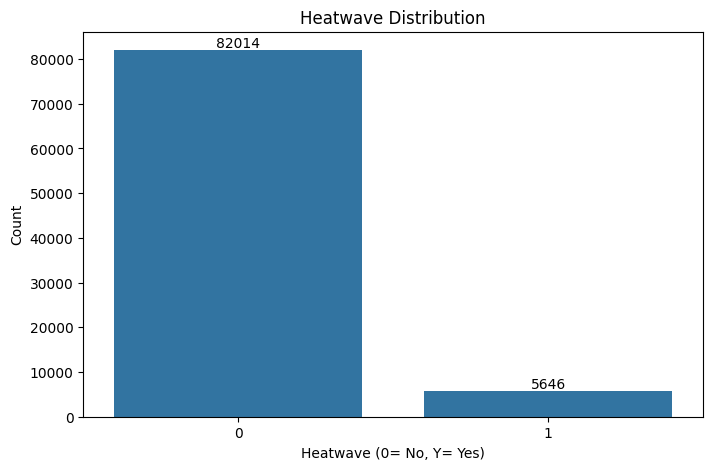

In [10]:
plt.figure(figsize=(8,5))
ax = sns.countplot(x='Heatwave', data=df)
ax.bar_label(ax.containers[0])

plt.title('Heatwave Distribution')
plt.xlabel('Heatwave (0= No, Y= Yes)')
plt.ylabel('Count')
plt.show()

### Maximum Temp Distribution

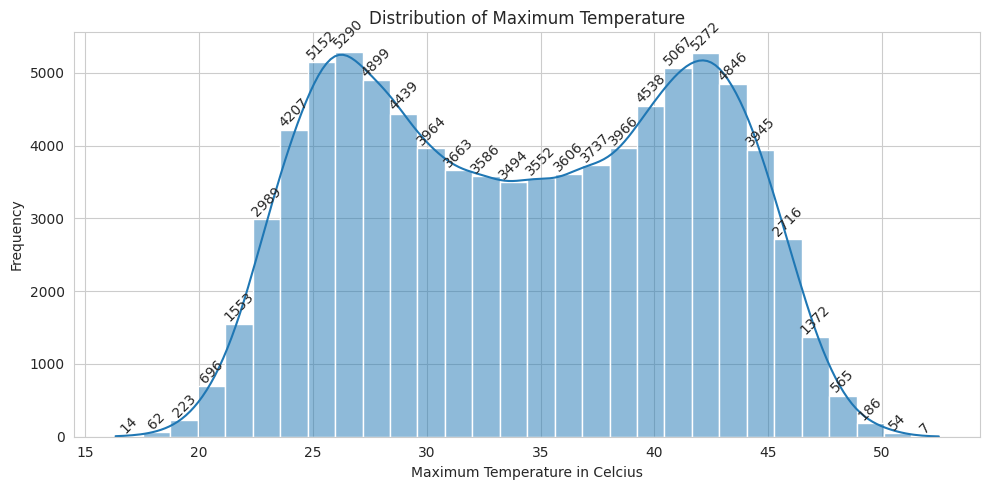

In [11]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,5))
ax = sns.histplot(df['Max_Temperature'], bins = 30, kde= True)
ax.bar_label(ax.containers[0], rotation = 45)
plt.title('Distribution of Maximum Temperature')
plt.xlabel('Maximum Temperature in Celcius')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

### Rainfall Distribution

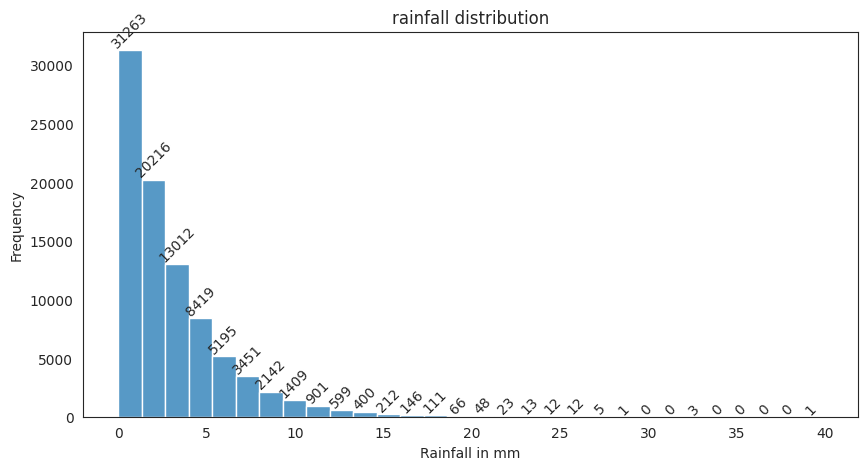

In [12]:
sns.set_style('white')
plt.figure(figsize=(10,5))
ax = sns.histplot(df['Rainfall'], bins = 30)
ax.bar_label(ax.containers[0], rotation = 45)
plt.title('rainfall distribution')
plt.xlabel('Rainfall in mm')
plt.ylabel('Frequency')
plt.show()

### Heatwave vs Maximum Temperature

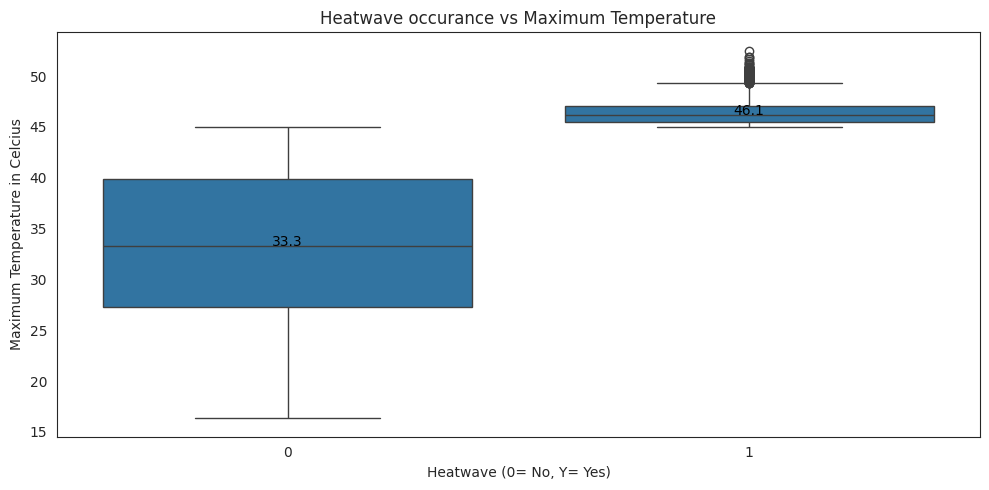

In [13]:
plt.figure(figsize=(10,5))

ax = sns.boxplot(x='Heatwave', y='Max_Temperature', data=df)

plt.title('Heatwave occurance vs Maximum Temperature')
plt.xlabel('Heatwave (0= No, Y= Yes)')
plt.ylabel('Maximum Temperature in Celcius')

medians = df.groupby('Heatwave')['Max_Temperature'].median()

for i, median in enumerate(medians):
    ax.text(i, median, f'{median:.1f}', ha='center', color= 'black')

plt.tight_layout()
plt.show()

### Monthly Temperature Trend

In [14]:
# Create month column
df['date'] = pd.to_datetime(df['Date'])
df['month'] = df['date'].dt.month

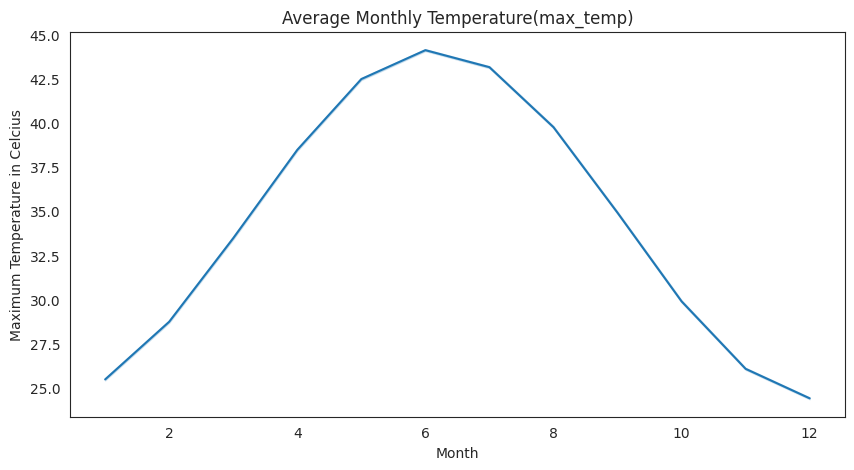

In [15]:
plt.figure(figsize=(10,5))

sns.lineplot(x='month', y='Max_Temperature', data=df)

plt.title('Average Monthly Temperature(max_temp)')
plt.xlabel('Month')
plt.ylabel('Maximum Temperature in Celcius')
plt.show()

### Statewise Temperature Variation

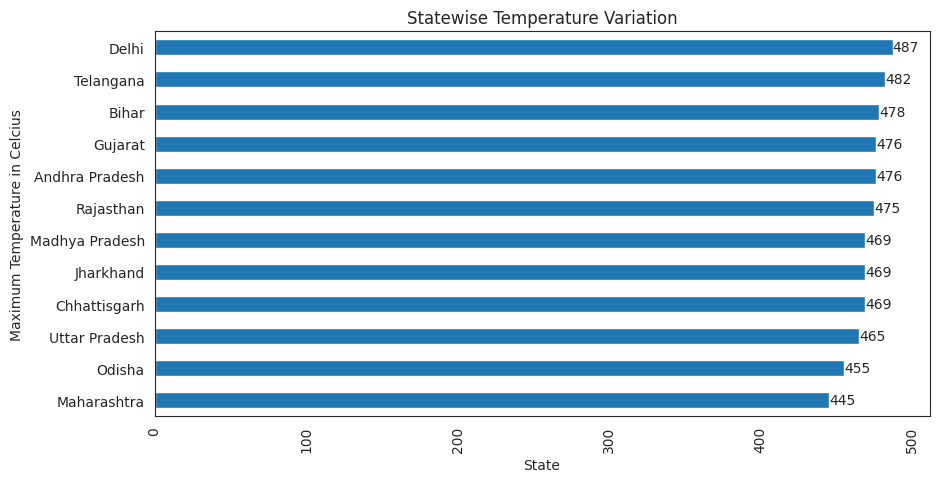

In [16]:
plt.figure(figsize=(10,5))

state_heatwave = df.groupby('State')['Heatwave'].sum().sort_values()
ax = state_heatwave.plot(kind='barh')
ax.bar_label(ax.containers[0])




plt.title('Statewise Temperature Variation')
plt.xlabel('State')
plt.xticks(rotation=90)
plt.ylabel('Maximum Temperature in Celcius')
plt.show()

### Correlation Heatmap

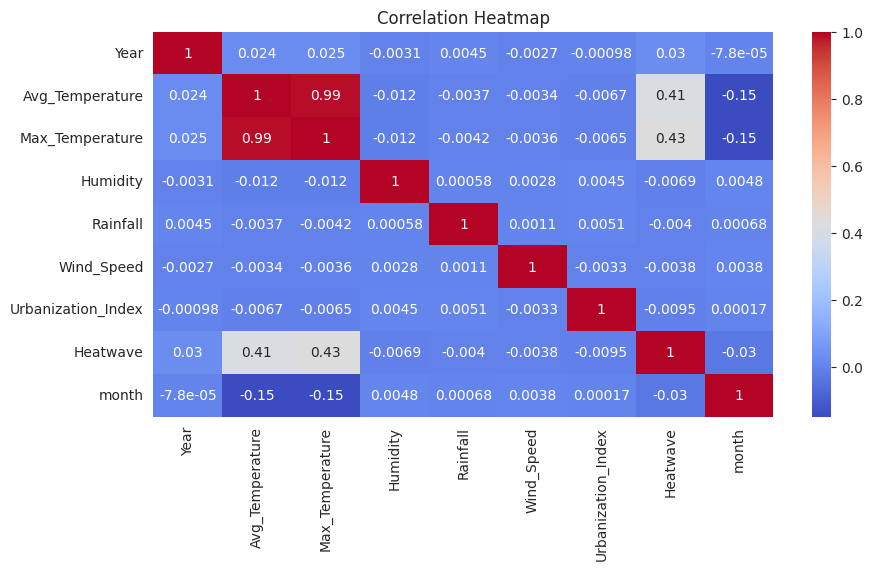

In [17]:
plt.figure(figsize=(10,5))

sns.heatmap(df.corr(numeric_only = True), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

### Relationship between multiple variables


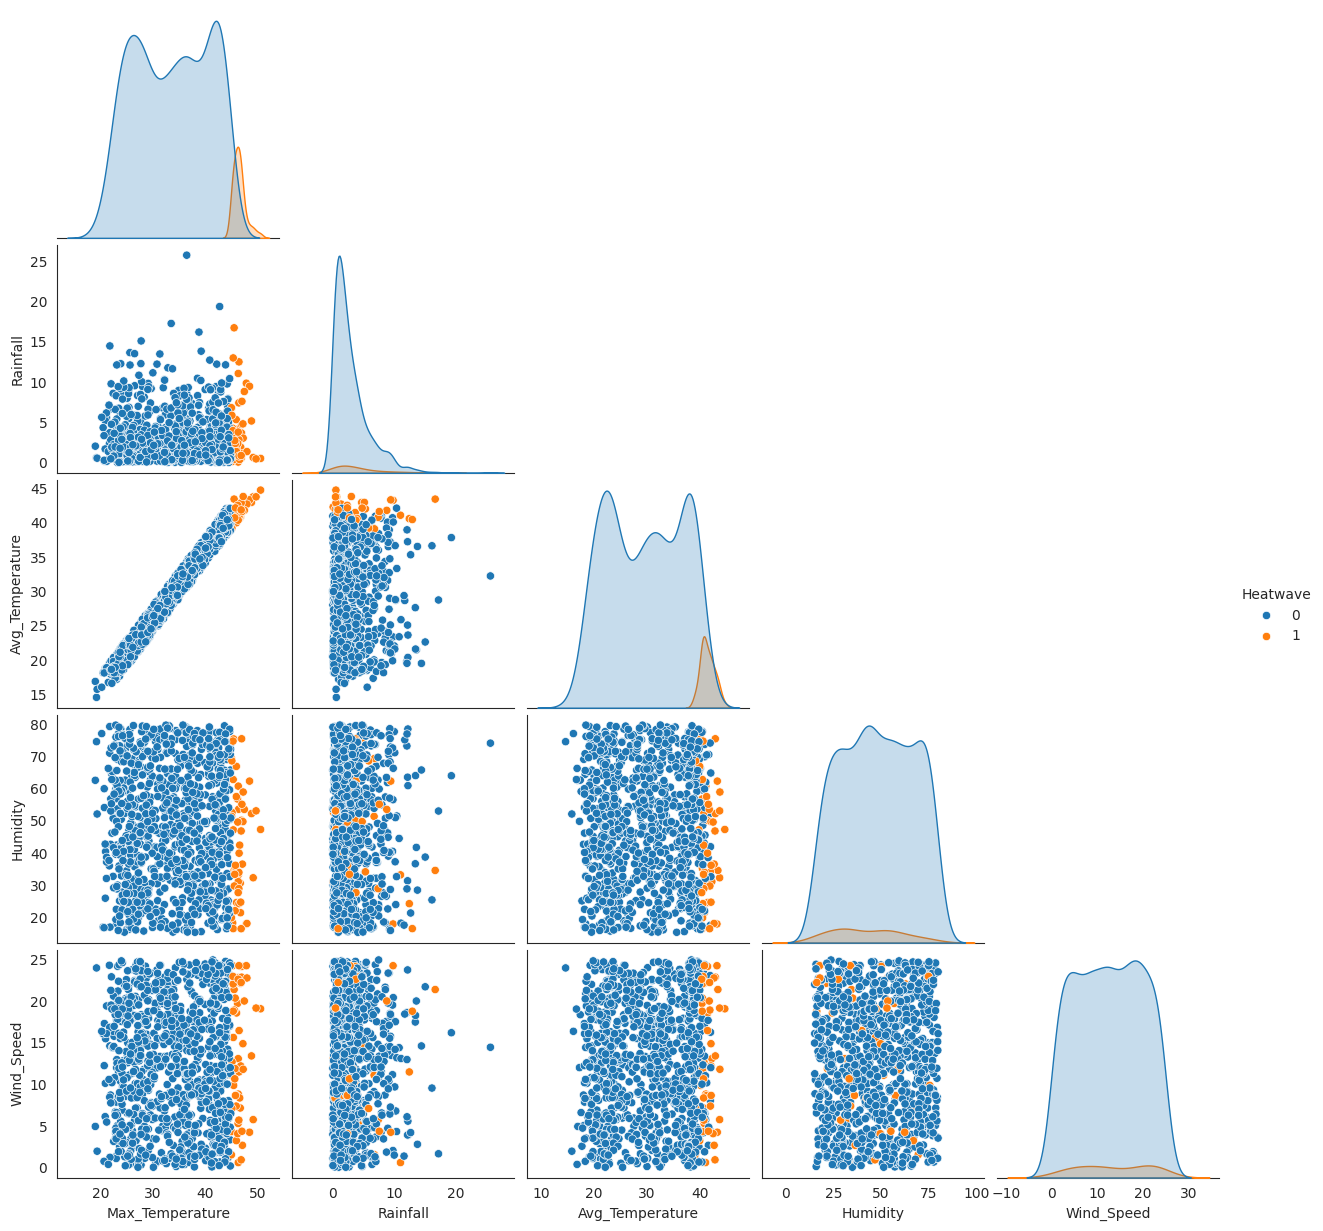

In [18]:
sample_df = df.sample(1000)             #Take 2000 random rows
sns.pairplot(sample_df[[
    'Max_Temperature',
    'Rainfall',
    'Heatwave',
    'Avg_Temperature',
    'Humidity',
    'Wind_Speed'
]], hue='Heatwave', corner=True)         #corner true removes duplicate plots

plt.show()

### Heatwave trend over years

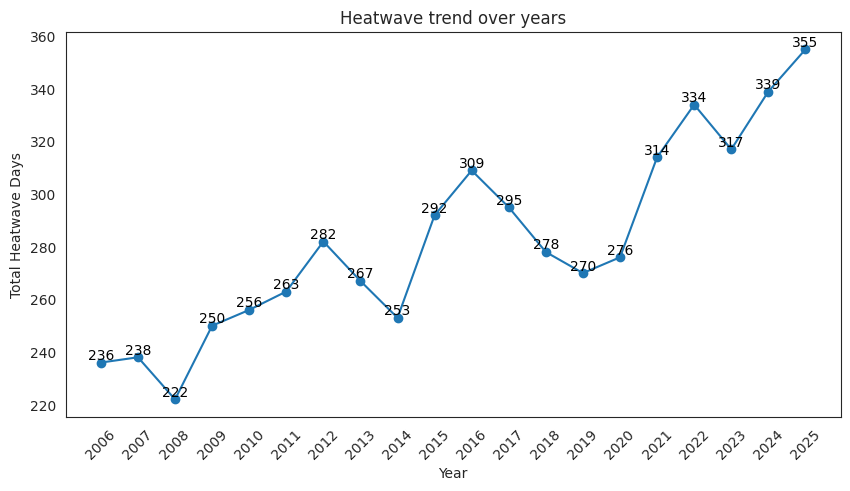

In [19]:
from matplotlib import markers
plt.figure(figsize=(10,5))
Year_heatwave = df.groupby(df['Date'].dt.year)['Heatwave'].sum()
ax = Year_heatwave.plot(marker = 'o')
plt.title('Heatwave trend over years')
plt.xlabel('Year')
plt.ylabel('Total Heatwave Days')

plt.xticks(Year_heatwave.index, rotation = 45)                # integer year ticks

for i, count in zip(Year_heatwave.index, Year_heatwave.values):
    ax.text(i, count, str(count), ha = 'center', va = 'bottom', color = 'black')

plt.show()

## **Feature Engineering**

It helps creating useful vaiables for the model.

In [20]:
#Covert date to datetime
df['Date'] = pd.to_datetime(df['Date'])

#Extract month and day to capture seasonal patterns.
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day

df.head()

,Date,Year,State,Avg_Temperature,Max_Temperature,Humidity,Rainfall,Wind_Speed,Urbanization_Index,Heatwave,date,month,day
0,2006-01-01,2006,Rajasthan,21.21,26.14,53.91,0.51,3.90,0.33,0,2006-01-01,1,1
1,2006-01-01,2006,Madhya Pradesh,19.94,25.41,54.07,3.69,0.51,0.88,0,2006-01-01,1,1
2,2006-01-01,2006,Uttar Pradesh,19.28,22.01,26.92,1.09,13.12,0.56,0,2006-01-01,1,1
3,2006-01-01,2006,Delhi,21.31,24.47,54.77,0.45,7.30,0.52,0,2006-01-01,1,1
4,2006-01-01,2006,Gujarat,23.15,25.95,48.43,2.69,1.16,0.66,0,2006-01-01,1,1


In [21]:
print(df.columns)

Index(['Date', 'Year', 'State', 'Avg_Temperature', 'Max_Temperature',
       'Humidity', 'Rainfall', 'Wind_Speed', 'Urbanization_Index', 'Heatwave',
       'date', 'month', 'day'],
      dtype='object')


## **Encoding Categorial Variables**

Machine learning models require numerical inputs. Here, the column state is categorial, so we convert it into numerical valuesusing label encoding.


In [22]:
le = LabelEncoder()
df['State'] = le.fit_transform(df['State'])

## **Define Features and Target**

Features (X): Climate variables

Target (y): Heatwave

In [23]:
print(df.columns)

Index(['Date', 'Year', 'State', 'Avg_Temperature', 'Max_Temperature',
       'Humidity', 'Rainfall', 'Wind_Speed', 'Urbanization_Index', 'Heatwave',
       'date', 'month', 'day'],
      dtype='object')


In [24]:
df.dtypes

,0
Date,datetime64[ns]
Year,int64
State,int64
Avg_Temperature,float64
Max_Temperature,float64
Humidity,float64
Rainfall,float64
Wind_Speed,float64
Urbanization_Index,float64
Heatwave,int64


In [25]:

X = df.drop(['Heatwave', 'date', 'Date'], axis=1)
y = df['Heatwave']

## **Train-Test Split**

Here, we split the data into:

Training - 80%

Testing - 20%

Training data is used to train the model and testing data used to evaluate model performance.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Model Selection**

we have to use Random forest classifier because:
* it works well with larger dataset
* Handles non linear relationships
* Reduces overfitting
* Provides feature importance

## **Train Random Forest model**

In [27]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## **Model Prediction**

In [28]:
y_pred = rf_model.predict(X_test)

## **Model Evalution**

We evalute the model by using Accuracy Score, Confusion Matrix, Classification report

In [29]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.999771845767739


In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16387
           1       1.00      1.00      1.00      1145

    accuracy                           1.00     17532
   macro avg       1.00      1.00      1.00     17532
weighted avg       1.00      1.00      1.00     17532



In [31]:
cm = confusion_matrix(y_test, y_pred)

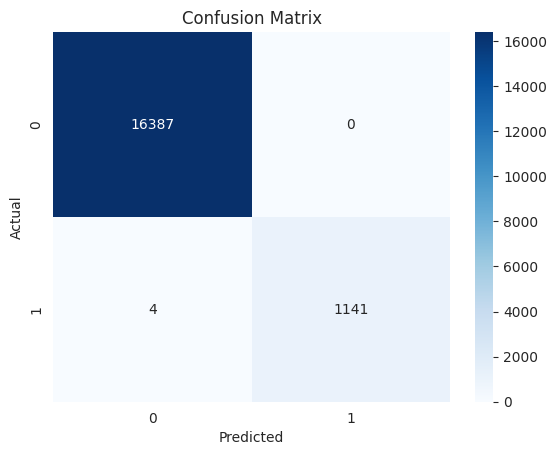

In [32]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## **Hyperparameter Tuning**

It improves model performance. We tune parameters like number of trees, max depth, min samples split

In [33]:
param_grid = {
    'n_estimators': [100, 200], #controls how many decision trees the random forest builds. 100 is baseline and 200 see if more trees improve accurancy
    'max_depth': [10, 20],      #controls how deep each decision tree can grow. 10 for simple trees and 20 for more complex trees
    'min_samples_split': [2, 5] #controls the minimum number of data points required to split a node. 2 rows can split and atleast 5 rows to split(this prevents overfitting)
}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
#cv is cross validation, used to evaluate how well the model generalizes to unseen data. the dataset is split multiple times for training and testing. Here data set is split into 3 equal parts and traimig happens 3 times and 3 testng is required.
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
print(grid.best_params_)



{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}


## **Cross Validation**

Cross-validation checks model stability by training and testing on multiple splits of data.

In [34]:
scores = cross_val_score(best_model, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Average score: ", scores.mean())

Cross-validation scores: [0.99994296 0.99960073 0.99994296 0.99982888 0.99994296]
Average score:  0.9998516997490302


## **Feature Importance**

Random forest allows us to see which features contirbute most to predictions.

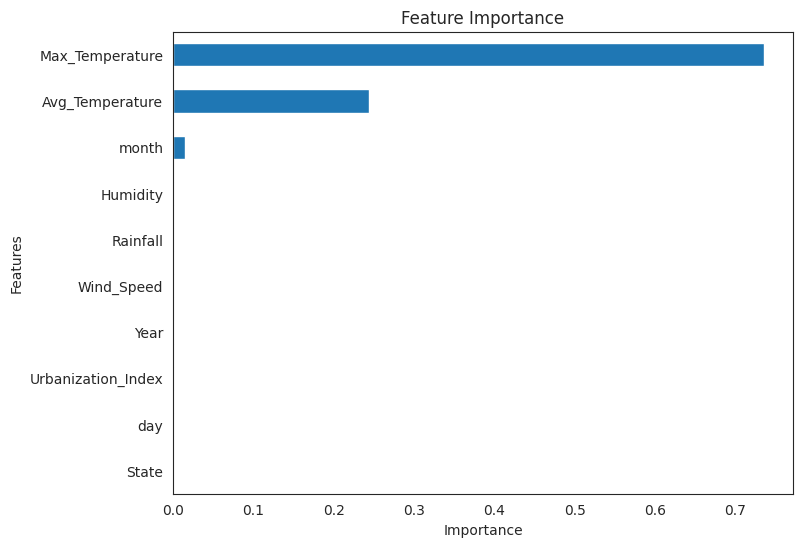

In [35]:
importance = best_model.feature_importances_
features = pd.Series(importance, index=X.columns)
features.sort_values().plot(kind='barh', figsize = (8,6))
plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('Feature Importance')
plt.show()

## **Future prediction for 2026**
Using this model , we can estimate heatwave likelihood for future prediction.

In [36]:
new_data = [[2026, 5, 40.0, 50.0, 25.0, 0.7, 5.0, 0.0, 5, 20]]

prediction = best_model.predict(new_data)

if prediction[0] == 1:
    print(f"\033[1;31mHeatwave predicted\033[0m")
else:
    print(f"\033[1;33mNoheat wave\033[0m")

Heatwave predicted


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
